Checking if the saved model works

In [4]:
import cv2
from tensorflow.keras.models import load_model
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [5]:
model_test = load_model("/mnt/c/Users/Praneeth Tadi/Documents/Coding/Machine Learning/ML Projects/Dog-cat-classify/dog-cat-classify/model/Dogcat-classifier.keras")

W0000 00:00:1781550641.412726  892666 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1781550641.417712  892666 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1781550641.687520  892666 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1746 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [6]:
image = 'Dog2.jpg'
image2 = 'Cat.jpg'
import os
if(os.path.exists(image)):
    image_ = cv2.imread(image)
    
    # convert image
    image_rgb = cv2.cvtColor(image_, cv2.COLOR_BGR2RGB)
    
    plt.imshow(image_rgb)
    
    plt.show()
    
    resize_img = cv2.resize(image_, (256, 256))
    resize_img = resize_img.reshape((1, 256, 256, 3))
    
    resize_img = resize_img / 255.
    
    pred = model_test.predict(resize_img)
    
    if(pred <= 0.5): 
        print("It is a cat")
    else: 
        print("It is a dog")
    
if(os.path.exists(image2)):
    image_ = cv2.imread(image2)
    
    # convert image
    image_rgb = cv2.cvtColor(image_, cv2.COLOR_BGR2RGB)
    
    plt.imshow(image_rgb)
    
    plt.show()
    
    resize_img = cv2.resize(image_, (256, 256))
    resize_img = resize_img.reshape((1, 256, 256, 3))
    
    resize_img = resize_img / 255.
    
    pred = model_test.predict(resize_img)
    
    if(pred <= 0.5): 
        print("It is a cat")
    else: 
        print("It is a dog")
    
    

The exported model works flawlessly. 

In [7]:
model_test.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,541,893 (169.91 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 29,694,596 (113.28 MB)

In [8]:
model_recent = load_model("/mnt/c/Users/Praneeth Tadi/Documents/Coding/Machine Learning/ML Projects/Dog-cat-classify/dog-cat-classify/model/Dogcat-classifier-v2.keras")
model_recent.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,037 (1.36 MB)

 Trainable params: 118,529 (463.00 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 237,060 (926.02 KB)

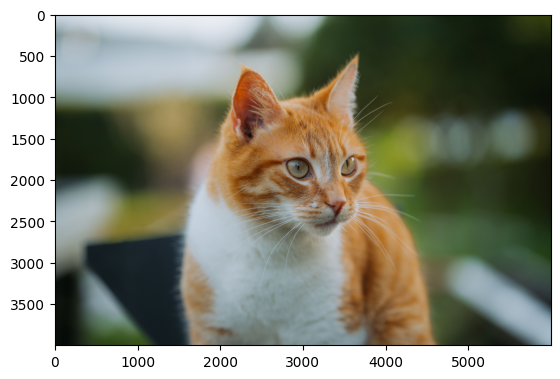

I0000 00:00:1781550650.633012  972427 service.cc:153] XLA service 0x7cdc9c034ee0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781550650.633050  972427 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1781550650.642830  972427 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781550650.708679  972427 cuda_dnn.cc:461] Loaded cuDNN version 92300


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


I0000 00:00:1781550652.502639  972427 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


It is a cat


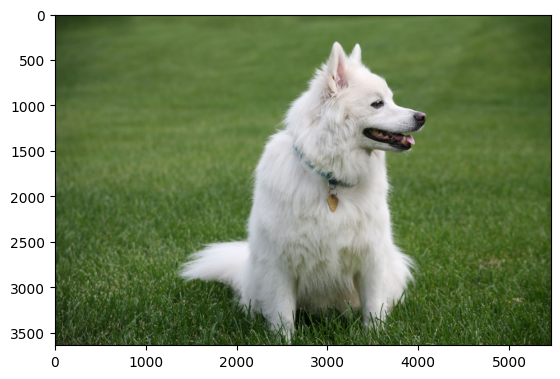

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
It is a cat


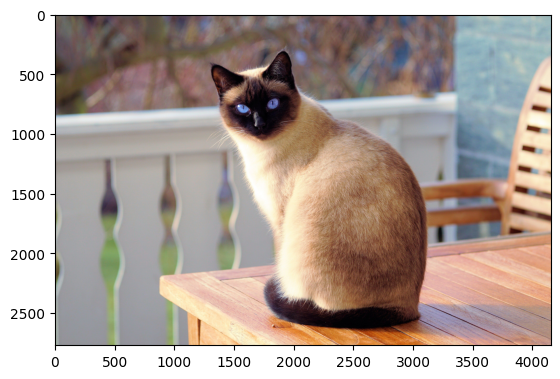

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
It is a cat


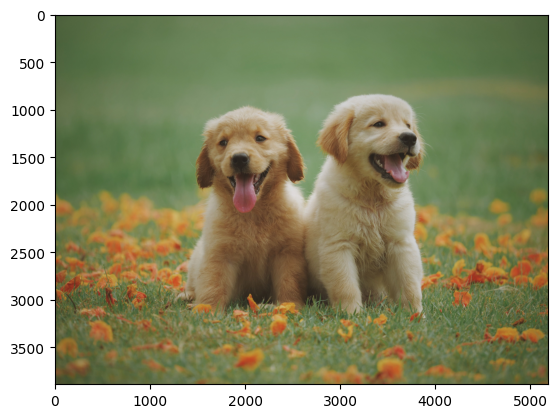

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
It is a dog


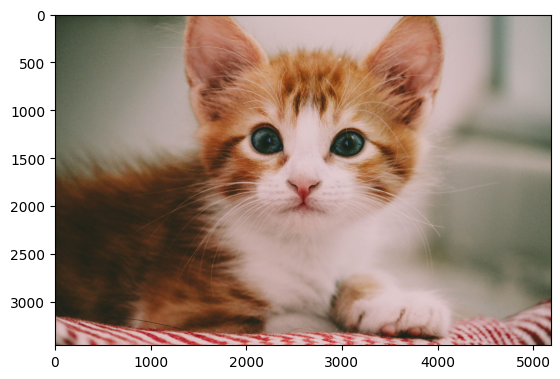

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
It is a cat


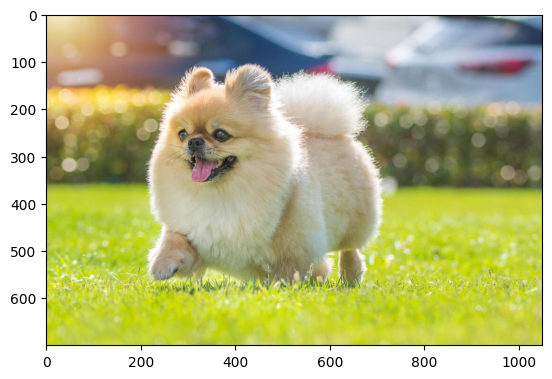

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
It is a cat


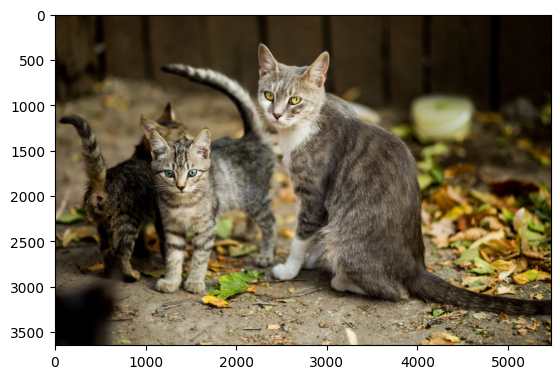

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
It is a dog


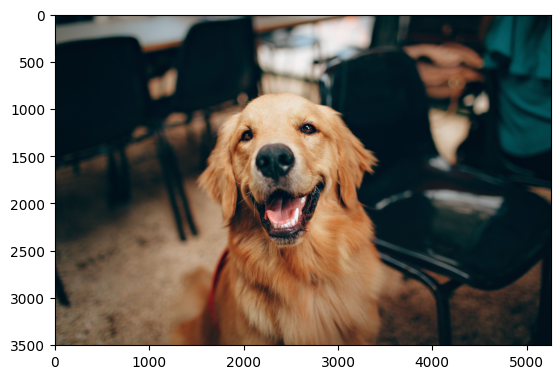

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
It is a cat


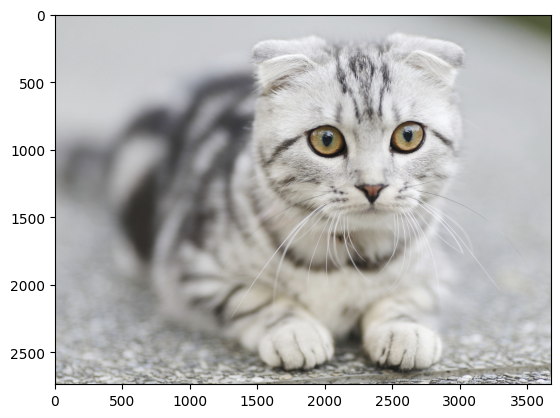

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
It is a cat


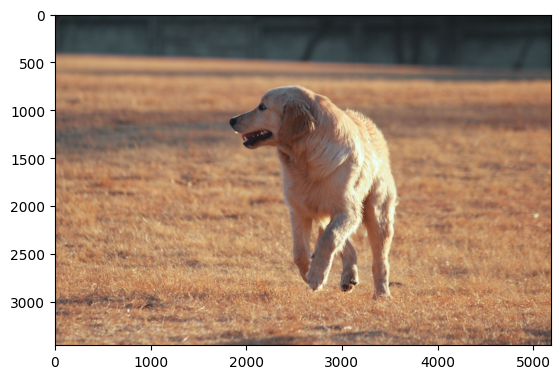

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
It is a cat


In [9]:
for i in range(1, 6): 
    image_cat = f"/mnt/c/Users/Praneeth Tadi/Documents/Coding/Machine Learning/ML Projects/Dog-cat-classify/dog-cat-classify/test_images/cat{i}.jpg"
    image_dog = f"/mnt/c/Users/Praneeth Tadi/Documents/Coding/Machine Learning/ML Projects/Dog-cat-classify/dog-cat-classify/test_images/dog{i}.jpg"
    if(os.path.exists(image_cat)):
        image_ = cv2.imread(image_cat)
        
        # convert image
        image_rgb = cv2.cvtColor(image_, cv2.COLOR_BGR2RGB)
        
        plt.imshow(image_rgb)
        
        plt.show()
        
        resize_img = cv2.resize(image_, (256, 256))
        resize_img = resize_img.reshape((1, 256, 256, 3))
        
        resize_img = resize_img / 255.
        
        pred = model_recent.predict(resize_img)
        
        if(pred <= 0.5): 
            print("It is a cat")
        else: 
            print("It is a dog")
        
    if(os.path.exists(image_dog)):
        image_ = cv2.imread(image_dog)
        
        
        # convert image
        image_rgb = cv2.cvtColor(image_, cv2.COLOR_BGR2RGB)
        
        plt.imshow(image_rgb)
        
        plt.show()
        
        resize_img = cv2.resize(image_, (256, 256))
        resize_img = resize_img.reshape((1, 256, 256, 3))
        
        resize_img = resize_img / 255.
        
        pred = model_recent.predict(resize_img)
        
        if(pred <= 0.5): 
            print("It is a cat")
        else: 
            print("It is a dog")

In [10]:
test_ds  = keras.utils.image_dataset_from_directory(directory="/mnt/c/Users/Praneeth Tadi/Documents/Coding/Machine Learning/ML Projects/Dog-cat-classify/dog-cat-classify/catsvsdogs/test", labels = 'inferred', label_mode= 'int', batch_size= 32, image_size=(256, 256))

Found 5000 files belonging to 2 classes.


In [11]:
test_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [12]:
model_recent.evaluate(test_ds)

W0000 00:00:1781550674.567200  972426 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.02GiB (rounded to 1090718976)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1781550674.569363  972426 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1781550674.569369  972426 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 88, Chunks in use: 88. 22.0KiB allocated for chunks. 22.0KiB in use in bin. 8.6KiB client-requested in use in bin.
I0000 00:00:1781550674.569376  972426 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 21, Chunks in use: 20. 11.0KiB allocated for chunks. 10.2KiB in use in bin. 10.0KiB client-requested in use in bin.
I0000 00:00:1781550674.569378  972426 bfc_allocator.cc:1056] Bin (1024): 	Total Chunks: 1, Chunks in use: 1. 1.2KiB allocated for

155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5265 - loss: 67.1201

I0000 00:00:1781550682.102826 1001534 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_6', 4 bytes spill stores, 4 bytes spill loads



157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.5148 - loss: 68.3772


[68.37720489501953, 0.5148000121116638]

In [13]:
test_ds = test_ds.map(
    lambda x, y: (x / 255.0, y)
)

In [14]:
model2 = load_model("/mnt/c/Users/Praneeth Tadi/Documents/Coding/Machine Learning/ML Projects/Dog-cat-classify/dog-cat-classify/model/Dogcat-classifier-v2.keras")

In [15]:
model2.evaluate(test_ds)

157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8588 - loss: 0.3446


[0.34463581442832947, 0.8587999939918518]